In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import mne
from scipy import signal, stats, optimize
import logging
from typing import Dict, List, Tuple, Optional
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import json
import warnings
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
features = pd.read_csv("eeg_features.csv")
features.head()

,subject_id,rpl_alpha,resting_alpha_power,resting_total_power,alpha_power_c3,alpha_power_c4,alpha_asymmetry,rpl_lower_beta,resting_lower_beta_power,rpl_upper_beta,...,pse_C4,pse_Cz,pse_avg,lzc_C3,lzc_C4,lzc_Cz,lzc_avg,theta_power,alpha_power,tar
0,S001,0.194741,8.242792e-12,4.232705e-11,6.628976e-12,1.039650e-11,0.450019,0.079778,3.376770e-12,0.086238,...,0.988388,0.994204,0.986577,0.002716,0.009505,0.013579,0.008600,5.685271e-12,6.728552e-12,0.053269
1,S002,0.202166,7.847295e-12,3.881609e-11,6.816839e-12,4.408732e-12,-0.435809,0.112889,4.381919e-12,0.209611,...,0.998837,0.987766,0.994784,0.005431,0.002716,0.021726,0.009958,3.514686e-12,3.428552e-12,0.033982
2,S003,0.099183,3.021946e-10,3.046833e-09,1.990851e-11,8.757055e-10,3.783883,0.061178,1.863987e-10,0.043745,...,0.952386,0.995225,0.976120,0.002716,0.005431,0.002716,0.003621,3.611554e-10,1.693918e-10,1.340632
3,S004,0.094906,2.162228e-12,2.278282e-11,2.793310e-12,2.282966e-12,-0.201752,0.075321,1.716026e-12,0.063961,...,0.999230,0.999874,0.999133,0.002716,0.002716,0.006789,0.004074,3.195265e-12,1.595437e-12,0.031451
4,S005,0.058463,4.349915e-12,7.440495e-11,4.316240e-12,5.436551e-12,0.230760,0.059404,4.419965e-12,0.042856,...,0.991964,0.998913,0.995943,0.105913,0.002716,0.109986,0.072872,7.541399e-12,4.122103e-12,0.072428


In [3]:
features.shape

(109, 41)

In [4]:
labels = pd.read_csv("ground_truth_cv_labels.csv")
labels.head()

,subject_id,mean_accuracy
0,S001,0.511111
1,S002,0.777778
2,S003,0.511111
3,S004,0.444444
4,S005,0.400000


In [5]:
labels.shape

(109, 2)

In [6]:
df = features.merge(labels, on = 'subject_id', how = 'inner')
df.head(5)

,subject_id,rpl_alpha,resting_alpha_power,resting_total_power,alpha_power_c3,alpha_power_c4,alpha_asymmetry,rpl_lower_beta,resting_lower_beta_power,rpl_upper_beta,...,pse_Cz,pse_avg,lzc_C3,lzc_C4,lzc_Cz,lzc_avg,theta_power,alpha_power,tar,mean_accuracy
0,S001,0.194741,8.242792e-12,4.232705e-11,6.628976e-12,1.039650e-11,0.450019,0.079778,3.376770e-12,0.086238,...,0.994204,0.986577,0.002716,0.009505,0.013579,0.008600,5.685271e-12,6.728552e-12,0.053269,0.511111
1,S002,0.202166,7.847295e-12,3.881609e-11,6.816839e-12,4.408732e-12,-0.435809,0.112889,4.381919e-12,0.209611,...,0.987766,0.994784,0.005431,0.002716,0.021726,0.009958,3.514686e-12,3.428552e-12,0.033982,0.777778
2,S003,0.099183,3.021946e-10,3.046833e-09,1.990851e-11,8.757055e-10,3.783883,0.061178,1.863987e-10,0.043745,...,0.995225,0.976120,0.002716,0.005431,0.002716,0.003621,3.611554e-10,1.693918e-10,1.340632,0.511111
3,S004,0.094906,2.162228e-12,2.278282e-11,2.793310e-12,2.282966e-12,-0.201752,0.075321,1.716026e-12,0.063961,...,0.999874,0.999133,0.002716,0.002716,0.006789,0.004074,3.195265e-12,1.595437e-12,0.031451,0.444444
4,S005,0.058463,4.349915e-12,7.440495e-11,4.316240e-12,5.436551e-12,0.230760,0.059404,4.419965e-12,0.042856,...,0.998913,0.995943,0.105913,0.002716,0.109986,0.072872,7.541399e-12,4.122103e-12,0.072428,0.400000


# Columns

In [7]:
for i in df.columns:
    print(i)

subject_id
rpl_alpha
resting_alpha_power
resting_total_power
alpha_power_c3
alpha_power_c4
alpha_asymmetry
rpl_lower_beta
resting_lower_beta_power
rpl_upper_beta
resting_upper_beta_power
smr_strength
IAF_c3
alpha_peak_amp_c3
beta_peak_amp_c3
beta_center_freq_c3
aperiodic_exp_c3
IAF_c4
alpha_peak_amp_c4
beta_peak_amp_c4
beta_center_freq_c4
aperiodic_exp_c4
alpha_var_C3
alpha_cv_C3
alpha_var_C4
alpha_cv_C4
coherence_mu
coherence_beta
coherence_low_beta
coherence_upper_beta
pse_C3
pse_C4
pse_Cz
pse_avg
lzc_C3
lzc_C4
lzc_Cz
lzc_avg
theta_power
alpha_power
tar
mean_accuracy


# Missing Values

In [8]:
missing_val_cols = []
for col in df.columns:
    if df[col].isna().sum() > 0:
        missing_val_cols.append(col)
        print(missing_val_cols[-1], ": ", df[col].isna().sum())


IAF_c3 :  50
IAF_c4 :  49


In [9]:
missing_df = df[['IAF_c3', 'IAF_c4']]
missing_df

,IAF_c3,IAF_c4
0,11.978944,NaN
1,11.726630,9.076708
2,NaN,NaN
3,NaN,10.131501
4,NaN,NaN
...,...,...
104,10.323881,NaN
105,NaN,9.757377
106,8.702243,9.736001
107,10.847895,10.807177


In [10]:
# check how many rows have at least one missing value
missing_df[(missing_df['IAF_c3'].isna()) | (missing_df['IAF_c4'].isna())]

,IAF_c3,IAF_c4
0,11.978944,NaN
2,NaN,NaN
3,NaN,10.131501
4,NaN,NaN
5,NaN,8.790012
...,...,...
100,NaN,NaN
103,NaN,9.197972
104,10.323881,NaN
105,NaN,9.757377


### Notes:
 - subjects with missing values in C3 or C4 are not the same . Many different subjects have one or both missing values from either electrode
 - missingness in those columns is caused by edge values for IAF, which are unreliable and best kept missing
 - Resting Alpha Power and IAF are related. For missing values, Resting alpha power can instead be used
 - About half of the rows have at least one missing value (over half, 66/109 = 61%)
 - Missingness Mechanism: Not Missing at Random (NMAR), because whether or not a value is missing depends on what that value would have been

# Initial dropping of redundant columns

In [11]:
to_drop = [
    'resting_alpha_power', # captured by rpl_alpha
    'resting_total_power', # captured by rpl_alpha
    'alpha_power_c3', # captured by rpl_alpha
    'alpha_power_c4',
    'resting_lower_beta_power', # captured by rpl_lower_beta
    'resting_upper_beta_power', # captured by rpl_upper_beta
    'coherence_beta', # captured by coherence_lower/upper_beta
    'pse_C3', # captured by pse_avg
    'pse_C4',
    'pse_Cz',
    'lzc_C3', # captured by lzc_avg
    'lzc_C4',
    'lzc_Cz',
    'theta_power', # captured by tar
    'alpha_power', # captured by tar
]

In [12]:
df = df.drop(columns = to_drop)

In [13]:
df.head(5)

,subject_id,rpl_alpha,alpha_asymmetry,rpl_lower_beta,rpl_upper_beta,smr_strength,IAF_c3,alpha_peak_amp_c3,beta_peak_amp_c3,beta_center_freq_c3,...,alpha_cv_C3,alpha_var_C4,alpha_cv_C4,coherence_mu,coherence_low_beta,coherence_upper_beta,pse_avg,lzc_avg,tar,mean_accuracy
0,S001,0.194741,0.450019,0.079778,0.086238,7.022793,11.978944,22.815138,12.760082,23.819507,...,0.061019,4.663400e-12,0.043488,0.141332,0.123185,0.109485,0.986577,0.008600,0.053269,0.511111
1,S002,0.202166,-0.435809,0.112889,0.209611,5.940523,11.726630,10.176643,34.331115,22.893572,...,0.024698,1.433725e-12,0.014019,0.175965,0.135896,0.144874,0.994784,0.009958,0.033982,0.777778
2,S003,0.099183,3.783883,0.061178,0.043745,4.247568,NaN,51.445281,7.098251,19.972889,...,0.046159,2.667545e-10,0.415862,0.123387,0.122145,0.121065,0.976120,0.003621,1.340632,0.511111
3,S004,0.094906,-0.201752,0.075321,0.063961,3.151023,NaN,79.301217,18.015913,23.955119,...,0.008185,7.108965e-13,0.006985,0.125134,0.110144,0.149414,0.999133,0.004074,0.031451,0.444444
4,S005,0.058463,0.230760,0.059404,0.042856,3.573126,NaN,51.986931,18.888159,19.707314,...,0.014593,3.416010e-12,0.031799,0.167894,0.148708,0.111603,0.995943,0.072872,0.072428,0.400000


# Averaging C3/C4 columns

In [14]:
for i in df.columns:
    print(i)

subject_id
rpl_alpha
alpha_asymmetry
rpl_lower_beta
rpl_upper_beta
smr_strength
IAF_c3
alpha_peak_amp_c3
beta_peak_amp_c3
beta_center_freq_c3
aperiodic_exp_c3
IAF_c4
alpha_peak_amp_c4
beta_peak_amp_c4
beta_center_freq_c4
aperiodic_exp_c4
alpha_var_C3
alpha_cv_C3
alpha_var_C4
alpha_cv_C4
coherence_mu
coherence_low_beta
coherence_upper_beta
pse_avg
lzc_avg
tar
mean_accuracy


In [15]:
# IAF avg - will actually keep both for now because of missing values

In [16]:
# Alpha peak amp
df['alpha_peak_amp'] = (df['alpha_peak_amp_c3'] + df['alpha_peak_amp_c4']) / 2

In [17]:
# beta peak amp
df['beta_peak_amp'] = (df['beta_peak_amp_c3'] + df['beta_peak_amp_c4']) / 2

In [18]:
# beta center freq
df['beta_center_freq'] = (df['beta_center_freq_c3'] + df['beta_center_freq_c4']) / 2

In [19]:
# aperiodic_exp_c4
df['aperiodic_exp'] = (df['aperiodic_exp_c3'] + df['aperiodic_exp_c4']) / 2

In [20]:
# alpha var
df['alpha_var'] = (df['alpha_var_C3'] + df['alpha_var_C4']) / 2

In [21]:
# alpha cv
df['alpha_cv'] = (df['alpha_cv_C3'] + df['alpha_cv_C4']) / 2

In [22]:
to_drop_avg = [
    'alpha_peak_amp_c3',
    'alpha_peak_amp_c4',
    'beta_peak_amp_c3',
    'beta_peak_amp_c4',
    'beta_center_freq_c3',
    'beta_center_freq_c4',
    'aperiodic_exp_c3',
    'aperiodic_exp_c4',
    'alpha_var_C3',
    'alpha_var_C4',
    'alpha_cv_C3',
    'alpha_cv_C4'
]

In [23]:
df = df.drop(columns = to_drop_avg)

In [24]:
df.head(5)

,subject_id,rpl_alpha,alpha_asymmetry,rpl_lower_beta,rpl_upper_beta,smr_strength,IAF_c3,IAF_c4,coherence_mu,coherence_low_beta,...,pse_avg,lzc_avg,tar,mean_accuracy,alpha_peak_amp,beta_peak_amp,beta_center_freq,aperiodic_exp,alpha_var,alpha_cv
0,S001,0.194741,0.450019,0.079778,0.086238,7.022793,11.978944,NaN,0.141332,0.123185,...,0.986577,0.008600,0.053269,0.511111,42.163593,9.505743,18.409753,0.5,5.632592e-12,0.052254
1,S002,0.202166,-0.435809,0.112889,0.209611,5.940523,11.726630,9.076708,0.175965,0.135896,...,0.994784,0.009958,0.033982,0.777778,27.169969,58.070694,23.234802,0.5,1.996023e-12,0.019358
2,S003,0.099183,3.783883,0.061178,0.043745,4.247568,NaN,NaN,0.123387,0.122145,...,0.976120,0.003621,1.340632,0.511111,72.389867,14.524291,22.830159,0.5,1.360196e-10,0.231010
3,S004,0.094906,-0.201752,0.075321,0.063961,3.151023,NaN,10.131501,0.125134,0.110144,...,0.999133,0.004074,0.031451,0.444444,73.945146,11.901924,22.401534,0.5,7.746218e-13,0.007585
4,S005,0.058463,0.230760,0.059404,0.042856,3.573126,NaN,NaN,0.167894,0.148708,...,0.995943,0.072872,0.072428,0.400000,29.900526,39.299466,16.353657,0.5,2.463477e-12,0.023196


In [25]:
df['bci_performance_labels'] = df['mean_accuracy']
df = df.drop(columns = ['mean_accuracy'])
df.head(5)

,subject_id,rpl_alpha,alpha_asymmetry,rpl_lower_beta,rpl_upper_beta,smr_strength,IAF_c3,IAF_c4,coherence_mu,coherence_low_beta,...,pse_avg,lzc_avg,tar,alpha_peak_amp,beta_peak_amp,beta_center_freq,aperiodic_exp,alpha_var,alpha_cv,bci_performance_labels
0,S001,0.194741,0.450019,0.079778,0.086238,7.022793,11.978944,NaN,0.141332,0.123185,...,0.986577,0.008600,0.053269,42.163593,9.505743,18.409753,0.5,5.632592e-12,0.052254,0.511111
1,S002,0.202166,-0.435809,0.112889,0.209611,5.940523,11.726630,9.076708,0.175965,0.135896,...,0.994784,0.009958,0.033982,27.169969,58.070694,23.234802,0.5,1.996023e-12,0.019358,0.777778
2,S003,0.099183,3.783883,0.061178,0.043745,4.247568,NaN,NaN,0.123387,0.122145,...,0.976120,0.003621,1.340632,72.389867,14.524291,22.830159,0.5,1.360196e-10,0.231010,0.511111
3,S004,0.094906,-0.201752,0.075321,0.063961,3.151023,NaN,10.131501,0.125134,0.110144,...,0.999133,0.004074,0.031451,73.945146,11.901924,22.401534,0.5,7.746218e-13,0.007585,0.444444
4,S005,0.058463,0.230760,0.059404,0.042856,3.573126,NaN,NaN,0.167894,0.148708,...,0.995943,0.072872,0.072428,29.900526,39.299466,16.353657,0.5,2.463477e-12,0.023196,0.400000


# Correlation between columns

In [26]:
correlation_matrix = df.drop(columns = ['subject_id']).corr()
correlation_matrix

,rpl_alpha,alpha_asymmetry,rpl_lower_beta,rpl_upper_beta,smr_strength,IAF_c3,IAF_c4,coherence_mu,coherence_low_beta,coherence_upper_beta,pse_avg,lzc_avg,tar,alpha_peak_amp,beta_peak_amp,beta_center_freq,aperiodic_exp,alpha_var,alpha_cv,bci_performance_labels
rpl_alpha,1.000000,0.081695,0.302155,0.234915,0.711264,0.305401,0.175095,0.340435,0.160128,0.105395,-0.421454,-0.013972,-0.178203,-0.088539,0.108142,-0.193105,-0.127680,0.058705,0.159210,0.442414
alpha_asymmetry,0.081695,1.000000,-0.013343,-0.139819,0.006906,0.301222,0.101497,0.057676,-0.012933,0.078052,-0.151031,-0.013902,0.531234,0.079074,-0.124324,-0.027082,-0.058937,0.518355,0.275347,-0.009266
rpl_lower_beta,0.302155,-0.013343,1.000000,0.564004,0.377726,0.182116,0.238941,0.172093,0.184541,0.102975,-0.147205,-0.004813,-0.178969,-0.059837,0.381015,0.133619,0.190197,0.085343,-0.152689,0.192863
rpl_upper_beta,0.234915,-0.139819,0.564004,1.000000,0.110340,0.137282,0.259959,0.266522,0.193642,0.242335,0.219587,0.055687,-0.290768,-0.279510,0.439740,0.321699,0.469736,-0.035246,-0.309151,0.059611
smr_strength,0.711264,0.006906,0.377726,0.110340,1.000000,0.266605,0.294220,0.158443,0.021964,0.004390,-0.656271,-0.012610,-0.112577,0.102135,0.360665,-0.235803,-0.242486,0.023708,0.275797,0.401878
IAF_c3,0.305401,0.301222,0.182116,0.137282,0.266605,1.000000,0.171875,0.248299,0.025942,0.109500,-0.109730,-0.235403,-0.173666,-0.026978,0.023078,0.020593,0.089018,-0.027852,-0.022433,0.284085
IAF_c4,0.175095,0.101497,0.238941,0.259959,0.294220,0.171875,1.000000,0.044656,0.148609,0.004248,-0.082677,-0.055768,-0.350616,-0.157368,0.255263,0.168128,0.104165,-0.128375,-0.153045,0.145316
coherence_mu,0.340435,0.057676,0.172093,0.266522,0.158443,0.248299,0.044656,1.000000,0.305187,0.377159,-0.057044,0.083460,-0.160820,-0.200923,-0.032203,-0.102473,0.183106,-0.064954,-0.089365,0.156497
coherence_low_beta,0.160128,-0.012933,0.184541,0.193642,0.021964,0.025942,0.148609,0.305187,1.000000,0.446310,0.144289,0.101994,-0.255520,-0.087549,0.110152,0.000652,0.159857,-0.109537,-0.263231,0.104801
coherence_upper_beta,0.105395,0.078052,0.102975,0.242335,0.004390,0.109500,0.004248,0.377159,0.446310,1.000000,-0.006644,0.020097,-0.155709,-0.206545,0.061887,0.159855,0.326341,-0.124254,-0.042054,-0.024916


In [27]:
for col in correlation_matrix.columns:
    for i in range(len(correlation_matrix)):
        if np.isclose(correlation_matrix[col].iloc[i], 1.0):
            continue
        elif np.abs(correlation_matrix[col].iloc[i]) > 0.65:
            print(f"{col:<30} {correlation_matrix.index[i]:<30} {correlation_matrix[col].iloc[i]:>10.3f}")

rpl_alpha                      smr_strength                        0.711
smr_strength                   rpl_alpha                           0.711
smr_strength                   pse_avg                            -0.656
pse_avg                        smr_strength                       -0.656
pse_avg                        alpha_cv                           -0.718
alpha_cv                       pse_avg                            -0.718


# Correlation Notes:

## Correlation notes (Old and irrelevant): 
## ***!!!(note: these notes were done before df cols were filtered for redundancy and averages)
- cols with consistently high correlation:
  - resting_alpha_power
  - resting_total_power
  - alpha_power_c4
  - resting_lower_beta_power
  - resting_upper_beta_power
  - alpha_var_C4
  - theta_power
  - alpha_power

- Also
  - alpha_var_c3 and alpha_cv_c3 are highly correlated (0.99) with each other
  - coherence_veta and coherence_upper_beta are highly correlated (0.919) with each other
  - pse_C3, pse_C4, and pse_avg are highly correlated via pse_avg (c3 and c4 not extremely correlated with each other)


Options I am considering:
- keeping one col per correlation block
  - If I keep resting alpha, the only other columns I keep are: alpha_cv_c3, pse_avg,
     - -> leads to resting_alpha_power, alpha_cv_c3, pse_avg
     - -> columns to drop: ["resting_total_power", "alpha_power_c4", "resting_lower_beta_power",
       "resting_upper_beta_power", "alpha_var_C4", "theta_power", "alpha_power", "alpha_var_C3",
       "coherence_beta", "coherence_upper_beta", "pse_C3", "pse_C4"]

- Ridge regression
- LASSO (automatic subset selection)
- Elastic net
- PCA to reduce dimensionality

In [28]:
# redundant = ["resting_total_power", "alpha_power_c4", "resting_lower_beta_power", "resting_upper_beta_power", 
#              "alpha_var_C4", "theta_power", "alpha_power", "alpha_var_C3", "coherence_beta", 
#              "coherence_upper_beta", "pse_C3", "pse_C4"]
# df_dropped_redundant = df[[col for col in df.columns if col not in redundant]]
# df_dropped_redundant.head()

### Interesting: rpl_alpha not correlated with resting alpha or total power, when it is the quotient of those
- direct algebraic dependence, which can be bad with my small N (109)

In [29]:
df['rpl_alpha'].describe()

count    109.000000
mean       0.155202
std        0.097238
min        0.037214
25%        0.093260
50%        0.121682
75%        0.190014
max        0.454908
Name: rpl_alpha, dtype: float64

### Notes to remember:
- use either rpl or absolute power consistently
- avg c3 and c4 features

In [30]:
df.head(5)

,subject_id,rpl_alpha,alpha_asymmetry,rpl_lower_beta,rpl_upper_beta,smr_strength,IAF_c3,IAF_c4,coherence_mu,coherence_low_beta,...,pse_avg,lzc_avg,tar,alpha_peak_amp,beta_peak_amp,beta_center_freq,aperiodic_exp,alpha_var,alpha_cv,bci_performance_labels
0,S001,0.194741,0.450019,0.079778,0.086238,7.022793,11.978944,NaN,0.141332,0.123185,...,0.986577,0.008600,0.053269,42.163593,9.505743,18.409753,0.5,5.632592e-12,0.052254,0.511111
1,S002,0.202166,-0.435809,0.112889,0.209611,5.940523,11.726630,9.076708,0.175965,0.135896,...,0.994784,0.009958,0.033982,27.169969,58.070694,23.234802,0.5,1.996023e-12,0.019358,0.777778
2,S003,0.099183,3.783883,0.061178,0.043745,4.247568,NaN,NaN,0.123387,0.122145,...,0.976120,0.003621,1.340632,72.389867,14.524291,22.830159,0.5,1.360196e-10,0.231010,0.511111
3,S004,0.094906,-0.201752,0.075321,0.063961,3.151023,NaN,10.131501,0.125134,0.110144,...,0.999133,0.004074,0.031451,73.945146,11.901924,22.401534,0.5,7.746218e-13,0.007585,0.444444
4,S005,0.058463,0.230760,0.059404,0.042856,3.573126,NaN,NaN,0.167894,0.148708,...,0.995943,0.072872,0.072428,29.900526,39.299466,16.353657,0.5,2.463477e-12,0.023196,0.400000


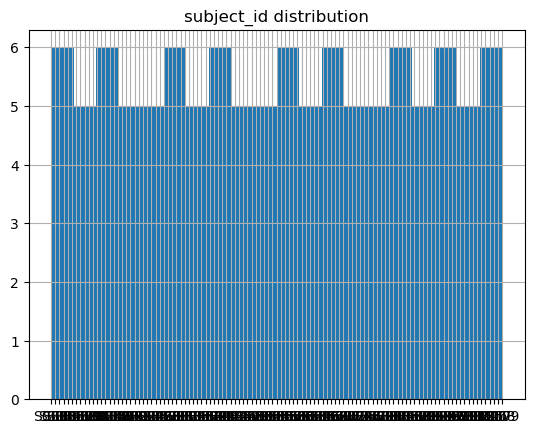

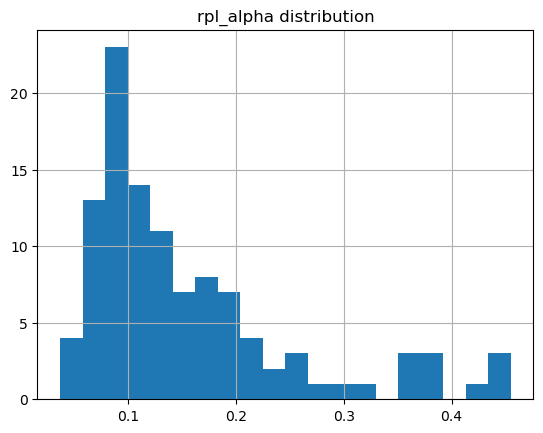

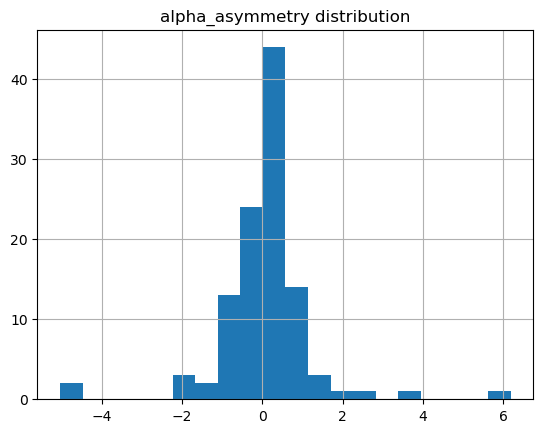

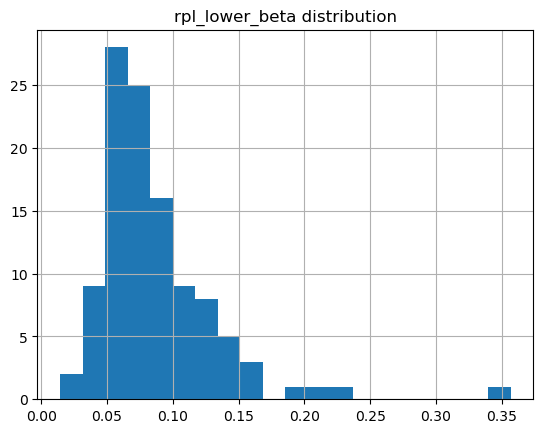

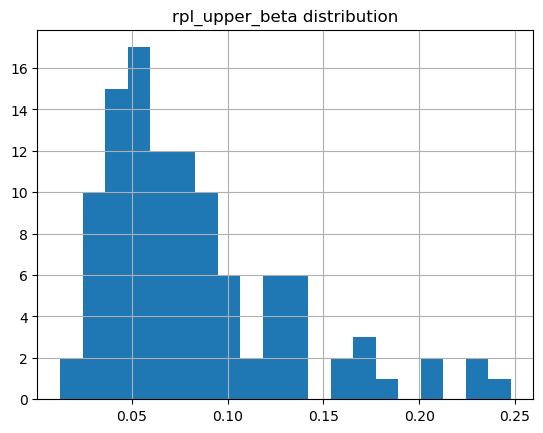

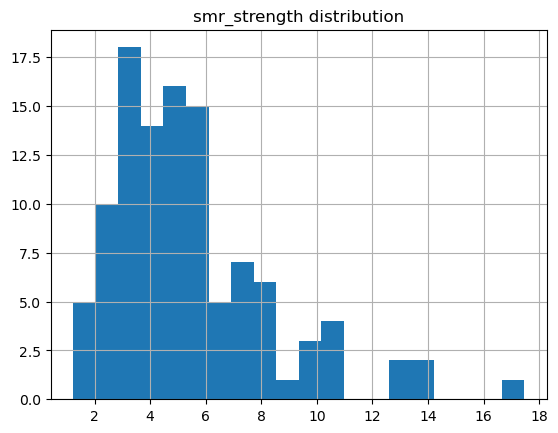

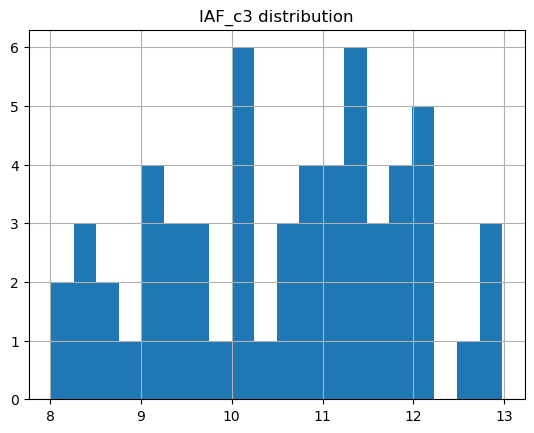

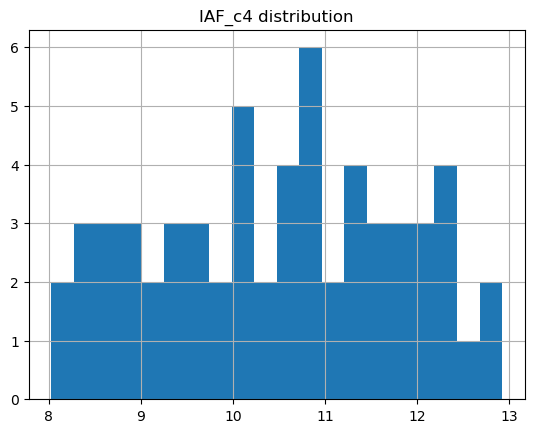

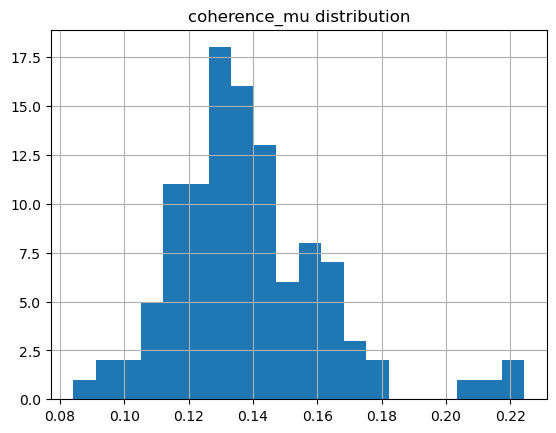

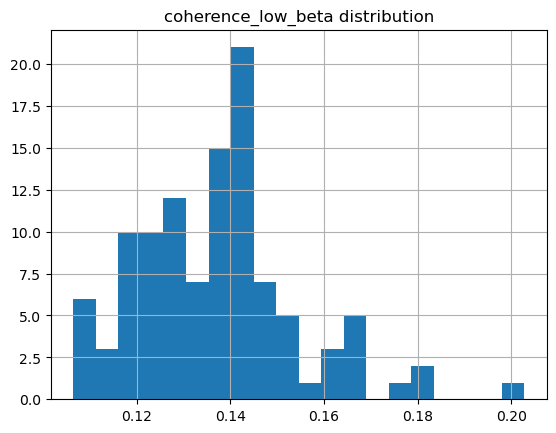

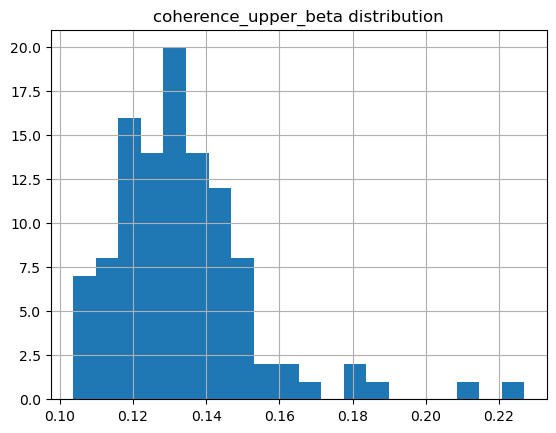

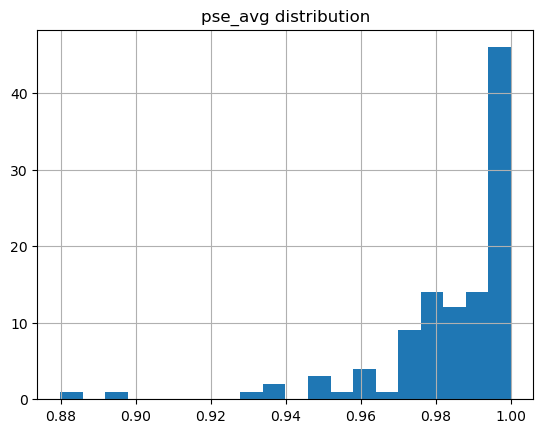

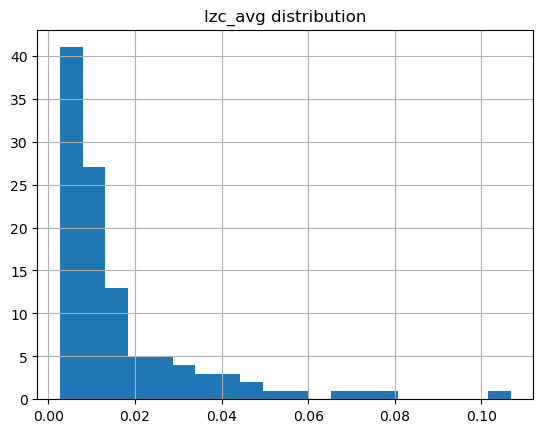

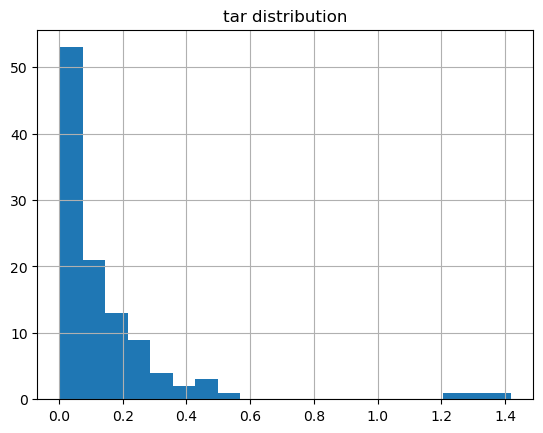

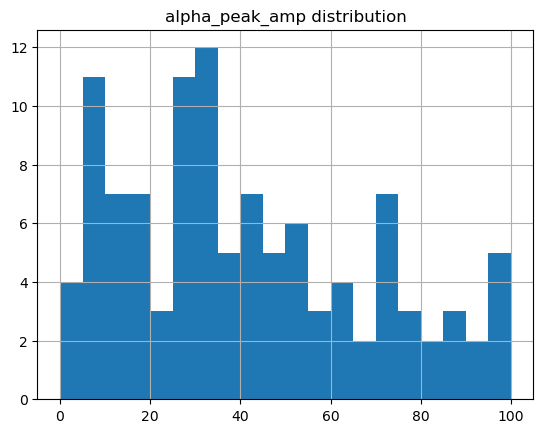

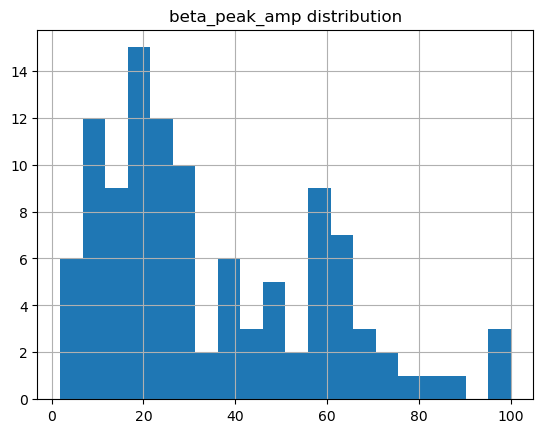

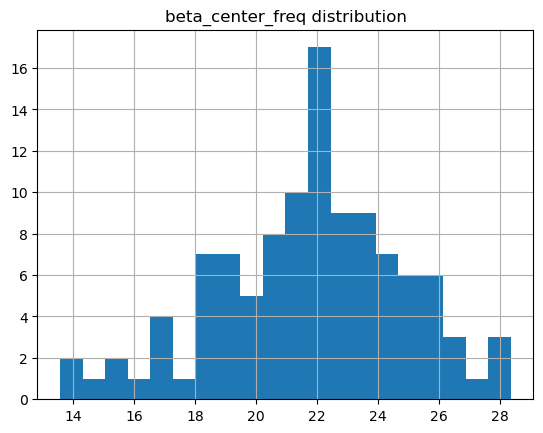

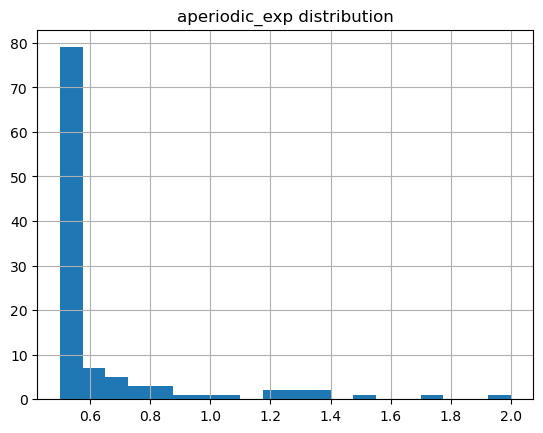

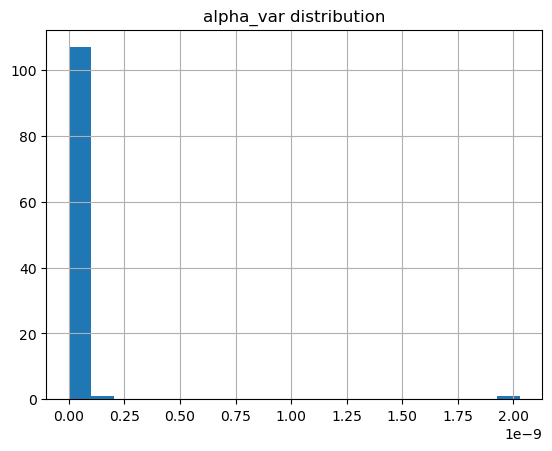

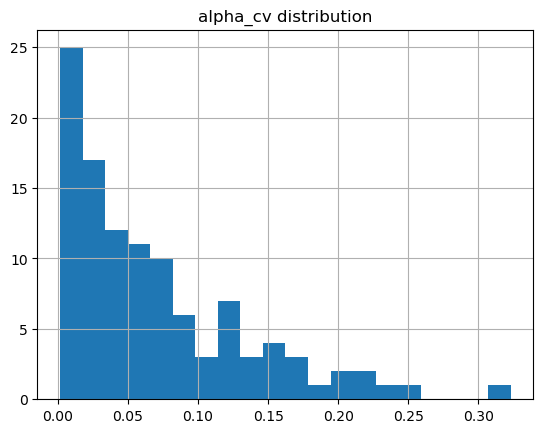

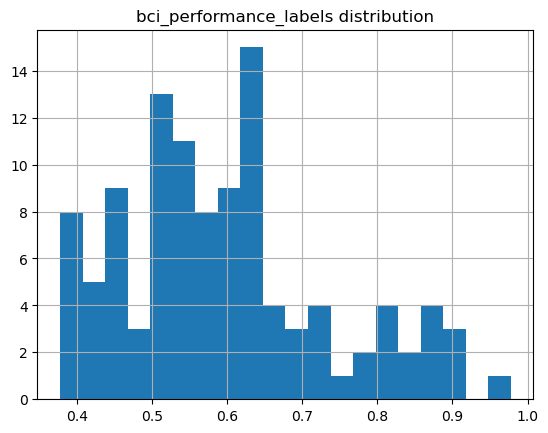

In [31]:
for col in df.columns:
    plt.figure()
    df[col].hist(bins = 20)
    plt.title(f"{col} distribution")
    plt.show()

In [32]:
df['alpha_var'].describe()

count    1.090000e+02
mean     2.849211e-11
std      1.941418e-10
min      1.515316e-13
25%      1.996023e-12
50%      5.435652e-12
75%      1.238221e-11
max      2.029498e-09
Name: alpha_var, dtype: float64

In [33]:
df['log_alpha_var'] = np.log10(df['alpha_var'])

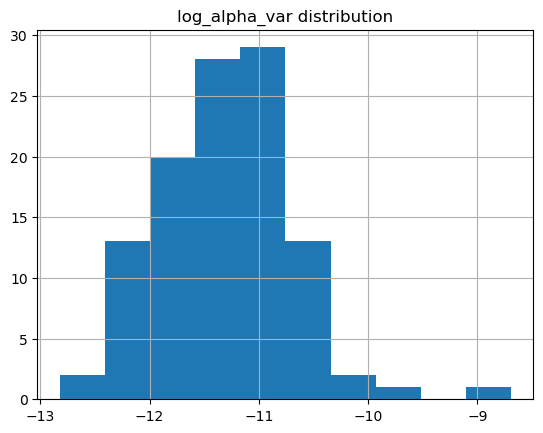

In [34]:
# alpha_var on improper axes
plt.figure()
df['log_alpha_var'].hist()
plt.title('log_alpha_var distribution')
plt.show()

# Next step: look at relationships between features and labels

In [35]:
df.columns

Index(['subject_id', 'rpl_alpha', 'alpha_asymmetry', 'rpl_lower_beta',
       'rpl_upper_beta', 'smr_strength', 'IAF_c3', 'IAF_c4', 'coherence_mu',
       'coherence_low_beta', 'coherence_upper_beta', 'pse_avg', 'lzc_avg',
       'tar', 'alpha_peak_amp', 'beta_peak_amp', 'beta_center_freq',
       'aperiodic_exp', 'alpha_var', 'alpha_cv', 'bci_performance_labels',
       'log_alpha_var'],
      dtype='object')

In [36]:
# note: does not include subject ID, labels, or log transformed alpha_var
numerical_cols = df.columns[1:-2]
numerical_cols

Index(['rpl_alpha', 'alpha_asymmetry', 'rpl_lower_beta', 'rpl_upper_beta',
       'smr_strength', 'IAF_c3', 'IAF_c4', 'coherence_mu',
       'coherence_low_beta', 'coherence_upper_beta', 'pse_avg', 'lzc_avg',
       'tar', 'alpha_peak_amp', 'beta_peak_amp', 'beta_center_freq',
       'aperiodic_exp', 'alpha_var', 'alpha_cv'],
      dtype='object')

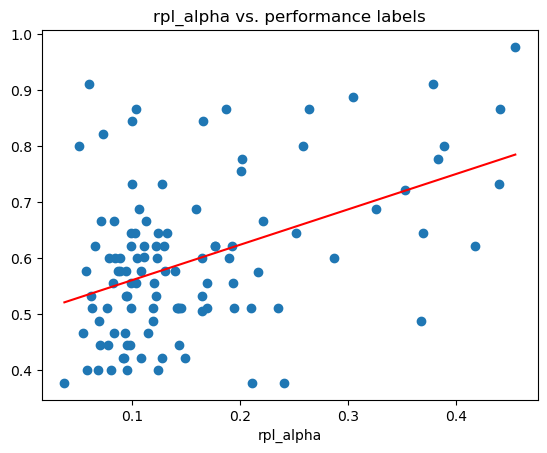

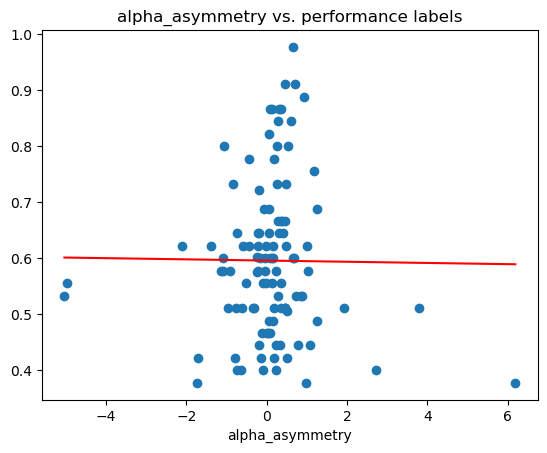

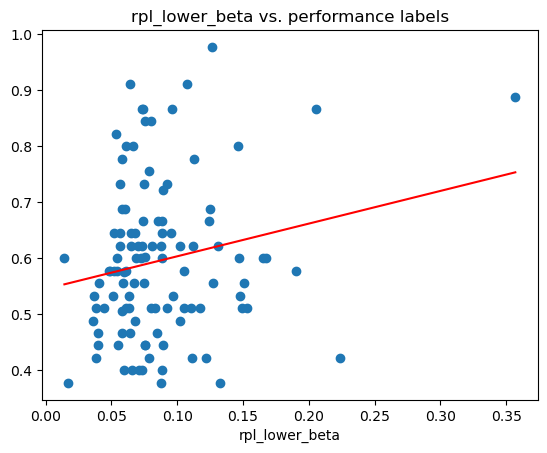

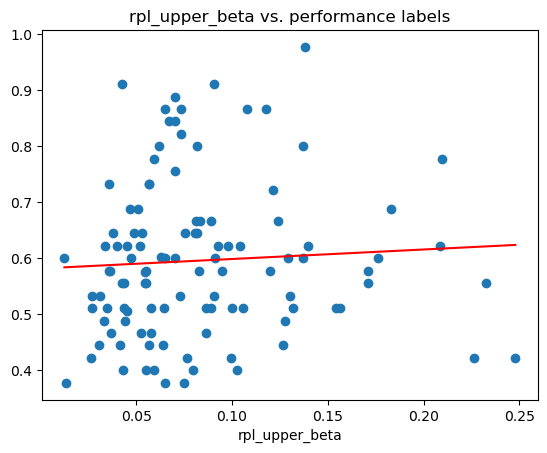

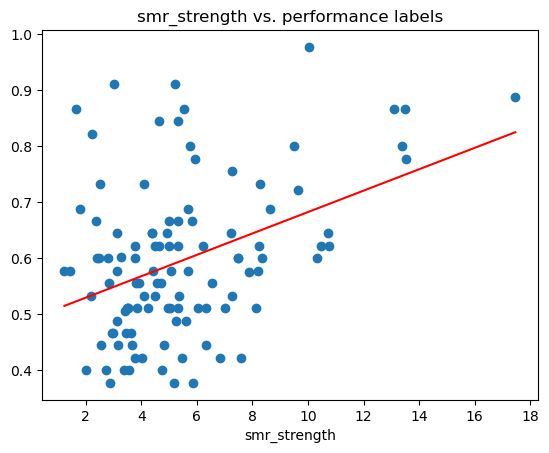

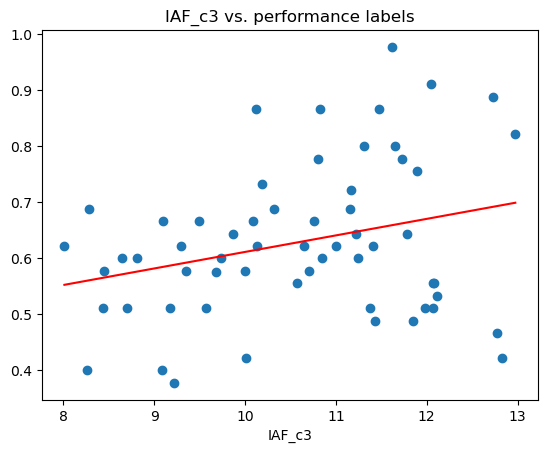

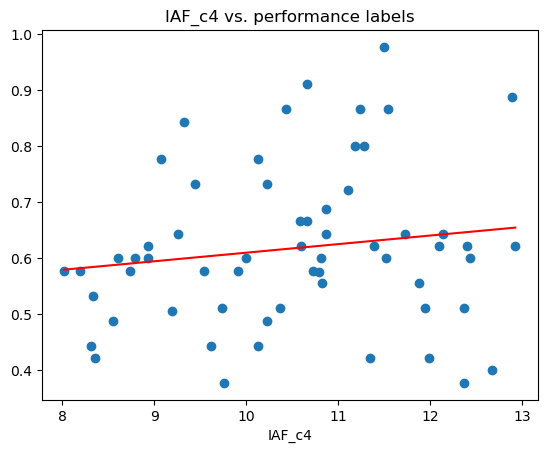

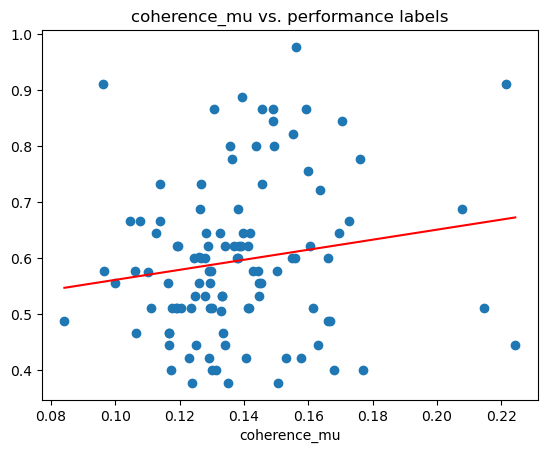

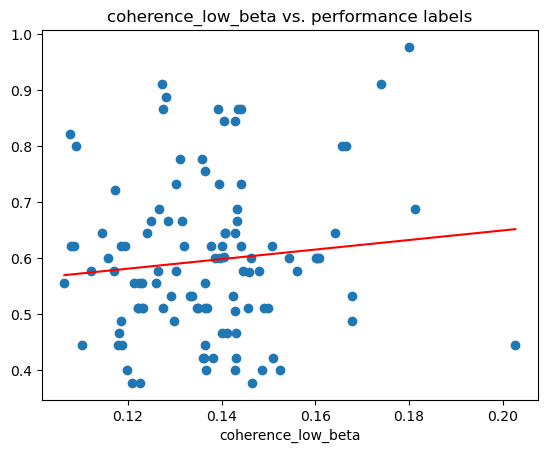

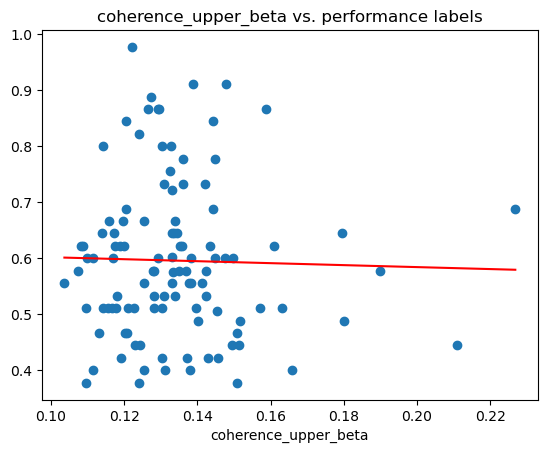

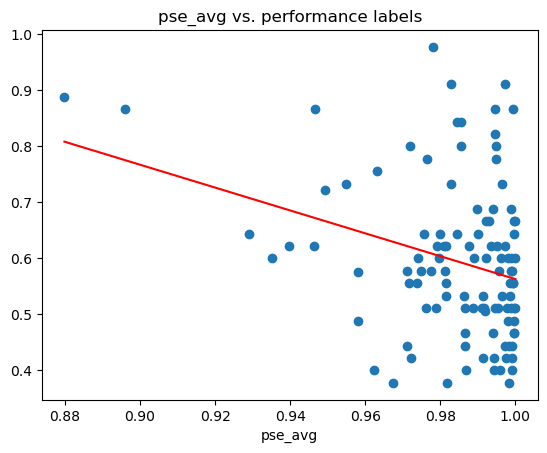

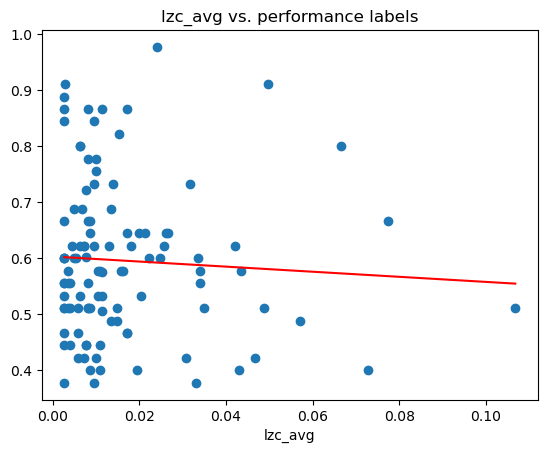

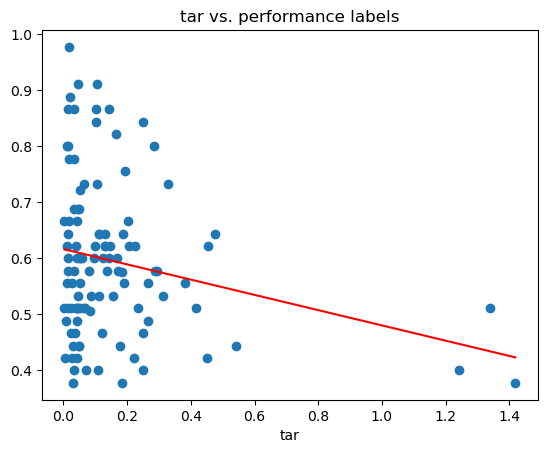

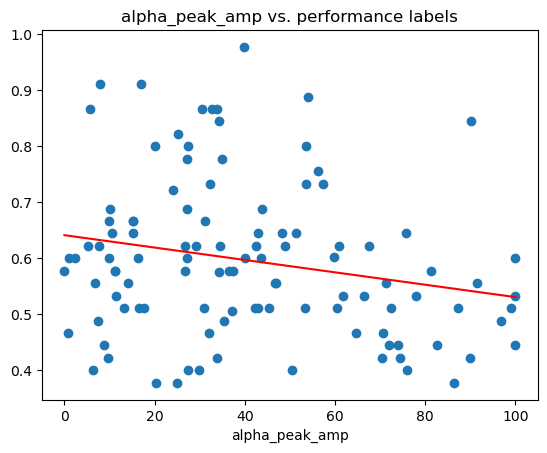

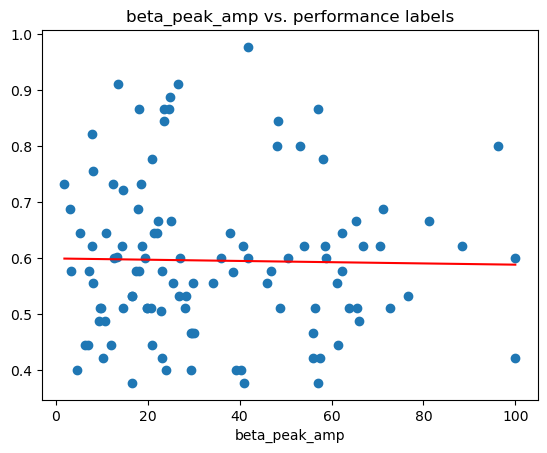

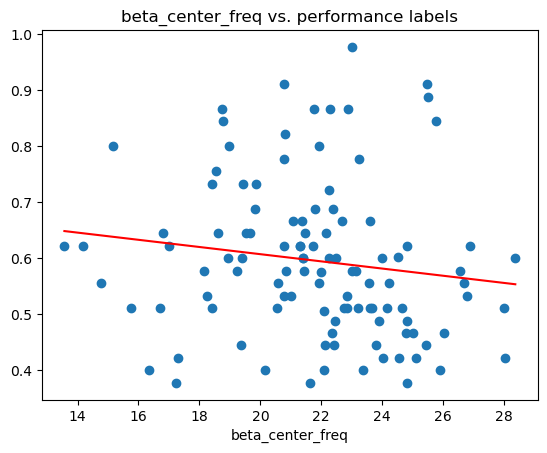

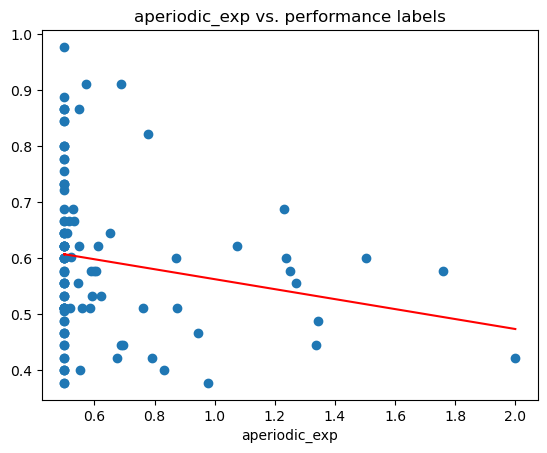

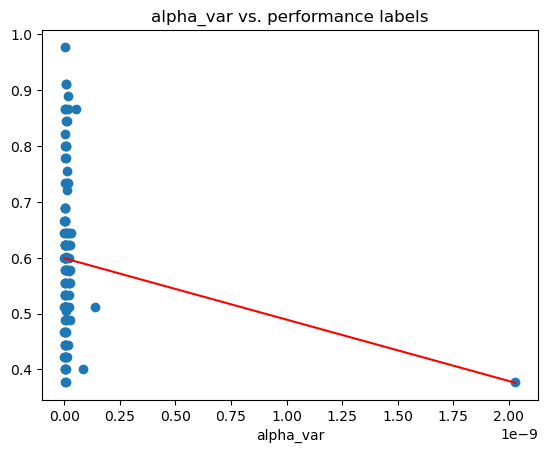

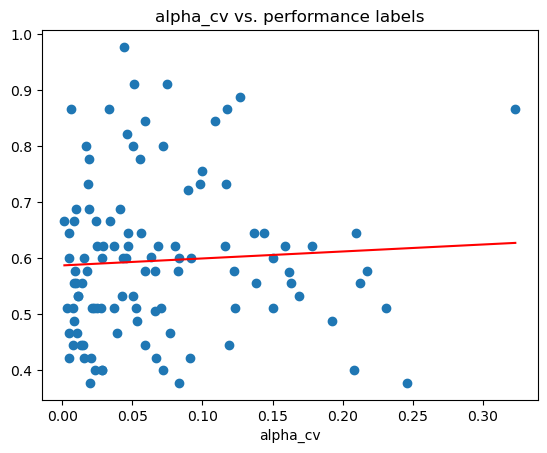

In [37]:
for i in numerical_cols:
    plt.figure()
    plt.scatter(df[i], df['bci_performance_labels'])

    mask = df[i].notna()
    x = df[i][mask].values
    y = df['bci_performance_labels'][mask].values
    m, b = np.polyfit(x, y, 1)
    plt.plot(np.sort(x), m * np.sort(x) + b, color = 'red')
    
    plt.title(f'{i} vs. performance labels')
    plt.xlabel(i)
    plt.show()

In [38]:
# Major findings
    # IAF_c3 and c4: point clouds with too many missing vals, will probably drop
    # beta_peak_amp and beta_center_freq: point clouds
    # floors for aperiodic_exp, tar, lzc_avg

# Next step: feature transformations according to distributions and scatter plots

In [39]:
# end goal: decide on ridge regression, LASSO, elastic net, or boosting/RF

In [40]:
df = df.drop(columns = 'log_alpha_var')
df_final = df.copy()
df_final

,subject_id,rpl_alpha,alpha_asymmetry,rpl_lower_beta,rpl_upper_beta,smr_strength,IAF_c3,IAF_c4,coherence_mu,coherence_low_beta,...,pse_avg,lzc_avg,tar,alpha_peak_amp,beta_peak_amp,beta_center_freq,aperiodic_exp,alpha_var,alpha_cv,bci_performance_labels
0,S001,0.194741,0.450019,0.079778,0.086238,7.022793,11.978944,NaN,0.141332,0.123185,...,0.986577,0.008600,0.053269,42.163593,9.505743,18.409753,0.500000,5.632592e-12,0.052254,0.511111
1,S002,0.202166,-0.435809,0.112889,0.209611,5.940523,11.726630,9.076708,0.175965,0.135896,...,0.994784,0.009958,0.033982,27.169969,58.070694,23.234802,0.500000,1.996023e-12,0.019358,0.777778
2,S003,0.099183,3.783883,0.061178,0.043745,4.247568,NaN,NaN,0.123387,0.122145,...,0.976120,0.003621,1.340632,72.389867,14.524291,22.830159,0.500000,1.360196e-10,0.231010,0.511111
3,S004,0.094906,-0.201752,0.075321,0.063961,3.151023,NaN,10.131501,0.125134,0.110144,...,0.999133,0.004074,0.031451,73.945146,11.901924,22.401534,0.500000,7.746218e-13,0.007585,0.444444
4,S005,0.058463,0.230760,0.059404,0.042856,3.573126,NaN,NaN,0.167894,0.148708,...,0.995943,0.072872,0.072428,29.900526,39.299466,16.353657,0.500000,2.463477e-12,0.023196,0.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,S105,0.159167,-0.078635,0.058281,0.046424,5.682607,10.323881,NaN,0.137988,0.143223,...,0.993945,0.006789,0.047761,27.194936,17.852206,21.797008,1.230626,1.961614e-12,0.018812,0.688889
105,S106,0.241051,0.968768,0.087498,0.065117,5.160030,NaN,9.757377,0.134915,0.122666,...,0.981856,0.002716,0.184921,20.418031,57.142423,17.236586,0.500000,9.617858e-12,0.083168,0.377778
106,S107,0.141917,0.349838,0.044266,0.034827,4.967701,8.702243,9.736001,0.141573,0.145677,...,0.990991,0.005884,0.066502,45.279323,9.764994,15.739743,0.500000,2.920401e-12,0.027406,0.511111
107,S108,0.286580,0.144540,0.053998,0.070020,10.306313,10.847895,10.807177,0.155908,0.160773,...,0.973940,0.004979,0.050994,27.266195,35.961636,21.409973,0.500000,9.297279e-12,0.082961,0.600000


In [41]:
# log transforming right-skewed features
old_to_drop = ['rpl_alpha', 'rpl_lower_beta', 'rpl_upper_beta', 'smr_strength', 'coherence_upper_beta', 'pse_avg', 'lzc_avg',
               'tar', 'aperiodic_exp', 'alpha_var', 'alpha_cv']

df_final['rpl_alpha_log'] = np.log10(df['rpl_alpha'])
df_final['rpl_lower_beta_log'] = np.log10(df['rpl_lower_beta'])
df_final['rpl_upper_beta_log'] = np.log10(df['rpl_upper_beta'])
df_final['smr_strength_log'] = np.log10(df['smr_strength'])
df_final['coherence_upper_beta_log'] = np.log10(df['coherence_upper_beta'])
df_final['pse_avg_log'] = np.log10(1 + 1 - df['pse_avg'])  # left skewed, reflect first
df_final['lzc_avg_log'] = np.log10(df['lzc_avg'])
df_final['tar_log'] = np.log10(df['tar'])
df_final['aperiodic_exp_log'] = np.log10(df['aperiodic_exp'])
df_final['alpha_var_log'] = np.log10(df['alpha_var'])
df_final['alpha_cv_log'] = np.log10(df['alpha_cv'])

df_final = df_final.drop(columns = old_to_drop)

df_final.columns

Index(['subject_id', 'alpha_asymmetry', 'IAF_c3', 'IAF_c4', 'coherence_mu',
       'coherence_low_beta', 'alpha_peak_amp', 'beta_peak_amp',
       'beta_center_freq', 'bci_performance_labels', 'rpl_alpha_log',
       'rpl_lower_beta_log', 'rpl_upper_beta_log', 'smr_strength_log',
       'coherence_upper_beta_log', 'pse_avg_log', 'lzc_avg_log', 'tar_log',
       'aperiodic_exp_log', 'alpha_var_log', 'alpha_cv_log'],
      dtype='object')

In [42]:
# additional transformations: IAF
    # IAF_c4 is a point cloud with a multimodal distribution -> drop
    # IAF_c3 is not much better but a weak linear relationship exists. 
        # add additional binary column by marking missing vals

df_final['has_IAF_c3'] = df_final['IAF_c3'].notna().astype(int)
IAF_median = df_final['IAF_c3'].median()
df_final['IAF_c3'] = df_final['IAF_c3'].fillna(IAF_median)  # median imputation
df_final = df_final.drop(columns = ['IAF_c4'])

In [43]:
# creating design matrix and label series

features = [col for col in df_final.columns if ((col != 'bci_performance_labels') and (col != 'subject_id'))]
X = df_final[features]
y = df_final['bci_performance_labels']

In [44]:
# Now: choosing regularized model
    # ridge: forces inclusion of all features, but possibly have many features that each contribute a little bit
    # LASSO: performs automatic subset selection, may drop some good features
    # elastic net: performs automatic subset selection, and can tune L1 (LASSO) vs. L2 (ridge) penalties

In [45]:
# # Elastic net: subset selection and tuning
# # LOOCV over CV: maxmizes training data, and only 109 subjects

# model = ElasticNetCV(
#     l1_ratio = [0.1, 0.25, 0.3, 0.5, 0.7, 0.75, 0.9, 0.95, 1.0],  # don't include 0 because want auto subset selection
#     n_alphas = 100,
#     cv = LeaveOneOut(),  # LOOCV
#     max_iter = 10000
# )

# model.fit(X, y)

# # best params
# print(f"best l1 ratio: {model.l1_ratio_}")
# print(f"best alpha: {model.alpha_}")

# # coefficients
# coefficients = pd.Series(model.coef_, index=features).sort_values(key= abs, ascending = False)
#     # series, features are index, values are coefficients for those features, sorted by descending absolute value

# # feature selection
# print(f"nonzero coefficients:\n {coefficients[coefficients != 0]}")
# print(f"number of kept features: {(coefficients != 0).sum()} / {len(coefficients)}")
# print(f"number of dropped features: {(coefficients == 0).sum()}")

In [46]:
# LASSO completely dominated over ridge, l1 ratio = 1.0 -> elastic net here == lasso

In [47]:
# model evaluation: r^2
loocv = LeaveOneOut()
y_pred = np.zeros(len(y))  # empty array, length 109

for train_idx, test_idx in loocv.split(X):  # split into 108 trains, 1 test

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train = y.iloc[train_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model_cv = ElasticNetCV(
        l1_ratio = [0.1, 0.25, 0.3, 0.5, 0.7, 0.75, 0.9, 0.95, 1.0],
        n_alphas = 100,
        cv = 5,
        max_iter = 10000
    )
    model_cv.fit(X_train_scaled, y_train)
    y_pred[test_idx] = model_cv.predict(X_test_scaled)

r2_score(y, y_pred)
        

0.07249572047432129

In [48]:
# yikes. Low performance. Maybe the nonlinear relationships are too much
    # next step: ensemble method

In [49]:
# random forest classifier (binary)

loocv = LeaveOneOut()
threshold = 0.6  # 70% accuracy is acceptable level for reliable MI-BCI performance, training can improve up to around 10%
y_class = (y >= threshold).astype(int)
y_pred_class = np.zeros(len(y_class))
print(f"High: {y_class.sum()}, Low: {(1-y_class).sum()}")

for train_idx, test_idx in loocv.split(X):  # split into 108 trains, 1 test

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train = y_class.iloc[train_idx]
    
    model_rf = RandomForestClassifier(
        n_estimators = 200,
        max_depth = 4,
        max_features = 5,
        class_weight = 'balanced'
    )

    model_rf.fit(X_train, y_train)
    y_pred_class[test_idx] = model_rf.predict(X_test)

print(f"LOOCV Accuracy: {accuracy_score(y_class, y_pred_class):.4f}")
print(f"Baseline: {max(y_class.mean(), 1-y_class.mean()):.4f}")

High: 51, Low: 58
LOOCV Accuracy: 0.5780
Baseline: 0.5321


In [50]:
# other metrics
print(confusion_matrix(y_class, y_pred_class))
print(classification_report(y_class, y_pred_class, target_names=['Low', 'High']))

[[38 20]
 [26 25]]
              precision    recall  f1-score   support

         Low       0.59      0.66      0.62        58
        High       0.56      0.49      0.52        51

    accuracy                           0.58       109
   macro avg       0.57      0.57      0.57       109
weighted avg       0.58      0.58      0.58       109



In [51]:
model_rf = RandomForestClassifier(
        n_estimators = 200,
        max_depth = 4,
        max_features = 5,
        class_weight = 'balanced'
    )
model_rf.fit(X, y_class)

importances = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

alpha_peak_amp              0.133784
smr_strength_log            0.125684
rpl_alpha_log               0.082702
beta_center_freq            0.079233
coherence_mu                0.055929
rpl_lower_beta_log          0.054498
pse_avg_log                 0.053473
alpha_asymmetry             0.051551
coherence_low_beta          0.046208
rpl_upper_beta_log          0.046017
alpha_cv_log                0.043797
coherence_upper_beta_log    0.041636
tar_log                     0.037766
beta_peak_amp               0.033186
IAF_c3                      0.029637
alpha_var_log               0.028596
aperiodic_exp_log           0.023987
lzc_avg_log                 0.020949
has_IAF_c3                  0.011367
dtype: float64


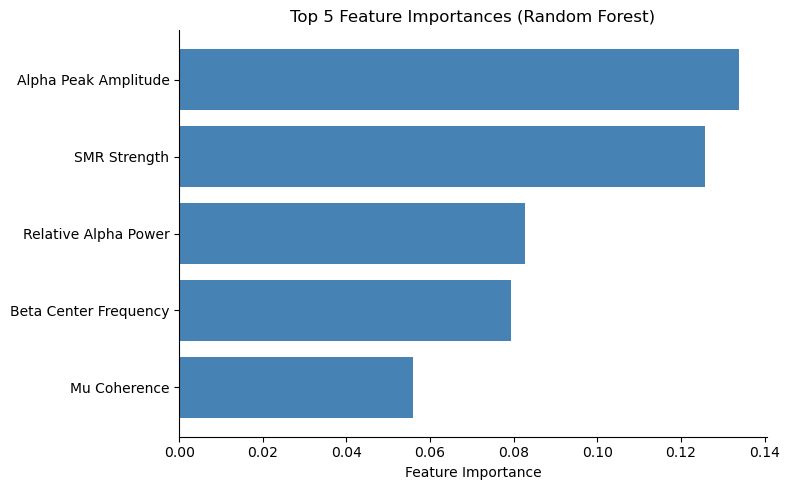

In [52]:
# feature importances
name_map = {
    'smr_strength_log': 'SMR Strength',
    'IAF_c3': 'Individual Alpha Frequency (C3)',
    'alpha_cv_log': 'Alpha Power CV',
    'rpl_lower_beta_log': 'Relative Lower Beta Power',
    'aperiodic_exp_log': 'Aperiodic Exponent',
    'rpl_alpha_log': 'Relative Alpha Power',
    'alpha_var_log': 'Alpha Power Variability',
    'alpha_peak_amp': 'Alpha Peak Amplitude',
    'beta_peak_amp': 'Beta Peak Amplitude',
    'beta_center_freq': 'Beta Center Frequency',
    'coherence_mu': 'Mu Coherence',
    'coherence_low_beta': 'Lower Beta Coherence',
    'coherence_upper_beta': 'Upper Beta Coherence',
    'coherence_beta': 'Beta Coherence',
    'rpl_upper_beta_log': 'Relative Upper Beta Power',
    'tar_log': 'Theta-Alpha Ratio',
    'lzc_avg_log': 'Lempel-Ziv Complexity',
    'pse_avg_log': 'Power Spectral Entropy',
    'has_IAF_c3': 'Has Alpha Peak (C3)'
}

top5 = importances.head(5)
top5_renamed = top5.rename(index=name_map)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top5_renamed.index[::-1], top5_renamed.values[::-1], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 5 Feature Importances (Random Forest)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

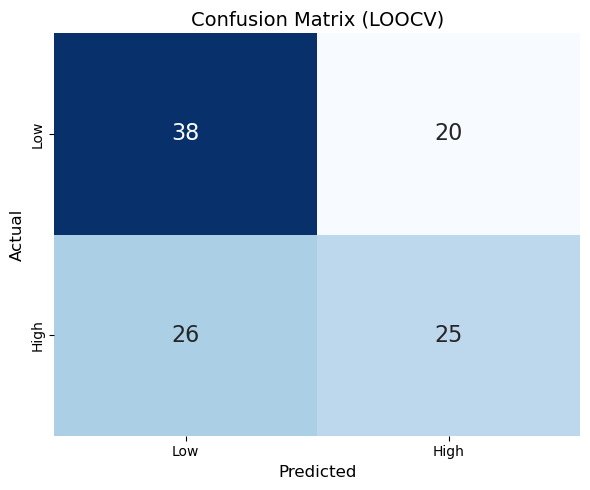

In [53]:
# confusion matrix
cm = confusion_matrix(y_class, y_pred_class)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Low', 'High'],
    yticklabels=['Low', 'High'],
    ax=ax,
    cbar=False,
    annot_kws={'size': 16}
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix (LOOCV)', fontsize=14)
plt.tight_layout()
plt.show()

In [54]:
# to control overfitting, I will try with a reduced feature set
df_final.columns

Index(['subject_id', 'alpha_asymmetry', 'IAF_c3', 'coherence_mu',
       'coherence_low_beta', 'alpha_peak_amp', 'beta_peak_amp',
       'beta_center_freq', 'bci_performance_labels', 'rpl_alpha_log',
       'rpl_lower_beta_log', 'rpl_upper_beta_log', 'smr_strength_log',
       'coherence_upper_beta_log', 'pse_avg_log', 'lzc_avg_log', 'tar_log',
       'aperiodic_exp_log', 'alpha_var_log', 'alpha_cv_log', 'has_IAF_c3'],
      dtype='object')

In [55]:
# chosen reduced feature set:

reduced_features = ['smr_strength_log', 'IAF_c3', 'has_IAF_c3', 'aperiodic_exp_log', 
                    'alpha_cv_log', 'rpl_lower_beta_log', 'bci_performance_labels']
df_reduced = df_final.set_index('subject_id')
df_reduced = df_reduced[reduced_features]
df_reduced.head(5)

,smr_strength_log,IAF_c3,has_IAF_c3,aperiodic_exp_log,alpha_cv_log,rpl_lower_beta_log,bci_performance_labels
subject_id,,,,,,,
S001,0.846510,11.978944,1,-0.30103,-1.281881,-1.098117,0.511111
S002,0.773825,11.726630,1,-0.30103,-1.713134,-0.947347,0.777778
S003,0.628140,10.762098,0,-0.30103,-0.636369,-1.213406,0.511111
S004,0.498452,10.762098,0,-0.30103,-2.120041,-1.123083,0.444444
S005,0.553048,10.762098,0,-0.30103,-1.634591,-1.226183,0.400000


Reduced LOOCV R²: 0.0649

Best l1_ratio: 0.1
Best alpha: 0.033916

Coefficients:
Has Alpha Peak (C3)                0.030998
Relative Lower Beta Power          0.024261
Aperiodic Exponent                -0.023729
Individual Alpha Frequency (C3)    0.019113
SMR Strength                       0.008691
Alpha Power CV                     0.006765
dtype: float64


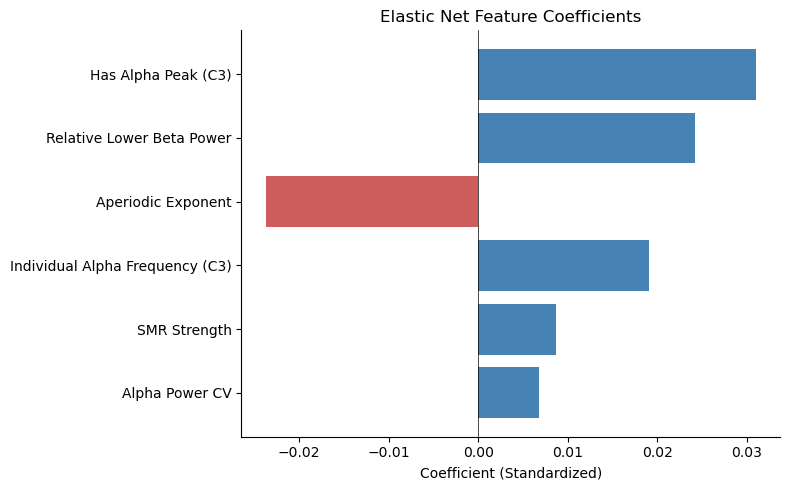

In [58]:
# reduced model evaluation
# LOOCV evaluation
loocv = LeaveOneOut()
X = df_reduced.drop(columns='bci_performance_labels')
y = df_reduced['bci_performance_labels']
y_pred = np.zeros(len(y))

for train_idx, test_idx in loocv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model_cv = ElasticNetCV(
        l1_ratio=[0.1, 0.25, 0.3, 0.5, 0.7, 0.75, 0.9, 0.95, 1.0],
        n_alphas=100,
        cv=5,
        max_iter=10000
    )
    model_cv.fit(X_train_scaled, y_train)
    y_pred[test_idx] = model_cv.predict(X_test_scaled)

print(f"Reduced LOOCV R²: {r2_score(y, y_pred):.4f}")

# Final model for coefficients
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)
enet_full = ElasticNetCV(
    l1_ratio=[0.1, 0.25, 0.3, 0.5, 0.7, 0.75, 0.9, 0.95, 1.0],
    n_alphas=100,
    cv=5,
    max_iter=10000
)
enet_full.fit(X_scaled_full, y)

# Coefficients
coefs = pd.Series(enet_full.coef_, index=X.columns)
coefs_renamed = coefs.rename(index=name_map)
coefs_sorted = coefs_renamed.reindex(coefs_renamed.abs().sort_values(ascending=False).index)

print(f"\nBest l1_ratio: {enet_full.l1_ratio_}")
print(f"Best alpha: {enet_full.alpha_:.6f}")
print(f"\nCoefficients:\n{coefs_sorted}")

# Coefficient plot (feature importance when standardized)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if c >= 0 else 'indianred' for c in coefs_sorted.values]
ax.barh(coefs_sorted.index[::-1], coefs_sorted.values[::-1], color=colors[::-1])
ax.set_xlabel('Coefficient (Standardized)')
ax.set_title('Elastic Net Feature Coefficients')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [59]:
# Random Forest reduced
loocv = LeaveOneOut()
threshold = 0.6  # 70% accuracy is acceptable level for reliable MI-BCI performance, training can improve up to around 10%
y_class = (y >= threshold).astype(int)
y_pred_class = np.zeros(len(y_class))
print(f"High: {y_class.sum()}, Low: {(1-y_class).sum()}")

for train_idx, test_idx in loocv.split(X):  # split into 108 trains, 1 test

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train = y_class.iloc[train_idx]
    
    model_rf = RandomForestClassifier(
        n_estimators = 200,
        max_depth = 4,
        max_features = 5,
        class_weight = 'balanced'
    )

    model_rf.fit(X_train, y_train)
    y_pred_class[test_idx] = model_rf.predict(X_test)

print(f"LOOCV Accuracy: {accuracy_score(y_class, y_pred_class):.4f}")
print(f"Baseline: {max(y_class.mean(), 1-y_class.mean()):.4f}")

High: 51, Low: 58
LOOCV Accuracy: 0.5872
Baseline: 0.5321


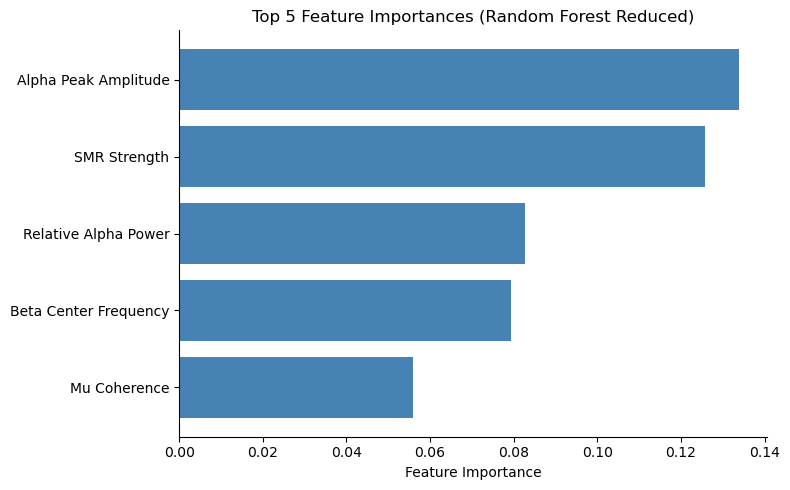

In [60]:
top5 = importances.head(5)
top5_renamed = top5.rename(index=name_map)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top5_renamed.index[::-1], top5_renamed.values[::-1], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 5 Feature Importances (Random Forest Reduced)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

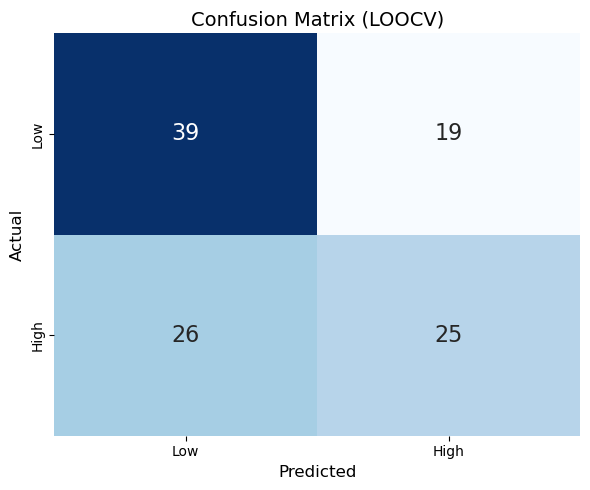

In [61]:
cm = confusion_matrix(y_class, y_pred_class)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Low', 'High'],
    yticklabels=['Low', 'High'],
    ax=ax,
    cbar=False,
    annot_kws={'size': 16}
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix (LOOCV)', fontsize=14)
plt.tight_layout()
plt.show()